In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import bundle_adjust
import glob
import json
import rpcm
import sys

print("ok")

ok


This notebook was created when lightglue was integrated into sat-bundleadjust

The goal was to verify that lightglue matching is better than epipolar-based matching for challening AOIs with strong seasonal changes

### Original epipolar-based matching

In [2]:
IMAGES_TO_IGNORE = {
    "JAX": ["6", "8", "9"],
    "UCSD": ["30", "31", "7"],
    "OMA": ["12"]
}

def rpc_from_json(json_path, return_dict=False):
    with open(json_path) as f:
        d = json.load(f)
    if return_dict:
        return d["rpc"]
    return rpcm.RPCModel(d["rpc"], dict_format="rpcm")

def run_ba(dataset_path, aoi_id, output_dir=None, save_tmp_files=False, overwrite=False, max_keypoints=None, dem_file=None):

    from bundle_adjust.cam_utils import SatelliteImage
    from bundle_adjust.ba_pipeline import BundleAdjustmentPipeline
    from bundle_adjust import loader

    run_ba = True

    img_dir = os.path.join(dataset_path, "crops", aoi_id)
    in_rpc_dir = os.path.join(dataset_path, "root", aoi_id)
    if output_dir is None:
        out_rpc_dir = os.path.join(dataset_path, "root_dir_ba", aoi_id)
        ba_files_dir = os.path.join(dataset_path, "ba_files", aoi_id)
    else:
        out_rpc_dir = os.path.join(output_dir, "root_dir_ba", aoi_id)
        ba_files_dir = os.path.join(output_dir, "ba_files", aoi_id)


    # overwrite if needed
    if os.path.exists(out_rpc_dir) and not overwrite:
        print("Output_dir already exists! Skipping!\n")
        return None
    else:
        os.makedirs(out_rpc_dir, exist_ok=True)

    # load input data
    myimages = sorted(glob.glob(img_dir + "/*.tif"))
    # Ignore badly localized images
    myimages = [im for im in myimages if os.path.basename(im).split("_")[-2].split(".")[0] not in IMAGES_TO_IGNORE.get(aoi_id.split("_")[0], [])]
    myjsons = [os.path.join(in_rpc_dir, os.path.basename(p).replace(".tif", ".json")) for p in myimages]
    for p1, p2 in zip(myjsons, myimages):
        assert os.path.exists(p1) and os.path.exists(p2)
    #myrpcs = [rpcm.rpc_from_geotiff(p) for p in mypanimages]
    myrpcs = [rpc_from_json(p) for p in myjsons]
    input_images = [SatelliteImage(fn, rpc) for fn, rpc in zip(myimages, myrpcs)]
    ba_input_data = {}
    ba_input_data['in_dir'] = img_dir
    ba_input_data['out_dir'] = ba_files_dir
    ba_input_data['images'] = input_images

    print('Input data successfully set!\n')

    # redirect all prints to a bundle adjustment logfile inside the output directory
    os.makedirs(ba_input_data['out_dir'], exist_ok=True)
    path_to_log_file = "{}/bundle_adjust.log".format(ba_input_data['out_dir'])
    print("Running bundle adjustment for RPC model refinement ...")
    print(f"Path to log file: {path_to_log_file}")
    log_file = open(path_to_log_file, "w+")
    sys.stdout = log_file
    sys.stderr = log_file
    # run bundle adjustment
    #tracks_config = {'FT_reset': True, 'FT_sift_detection': 's2p', 'FT_sift_matching': 'epipolar_based', "FT_K": 300}
    # tracks_config = {'FT_reset': False, 'FT_save': True, 'FT_sift_detection': 's2p', 'FT_sift_matching': 'epipolar_based', "FT_kp_max": 20000, "FT_n_proc": 12}
    if max_keypoints is None:
        tracks_config = {'FT_reset': False, 'FT_save': True, 'FT_sift_detection': 's2p', 'FT_sift_matching': 'epipolar_based', "FT_n_proc": 12}
    else:
        tracks_config = {'FT_reset': False, 'FT_save': True, 'FT_sift_detection': 's2p', 'FT_sift_matching': 'epipolar_based', "FT_kp_max": max_keypoints, "FT_n_proc": 12}
    ba_extra = {"cam_model": "rpc", "dem_file": dem_file}
    ba_pipeline = BundleAdjustmentPipeline(ba_input_data, tracks_config=tracks_config, extra_ba_config=ba_extra)
    ba_pipeline.run()
    # close logfile
    sys.stderr = sys.__stderr__
    sys.stdout = sys.__stdout__
    log_file.close()
    print("... done !")
    print(f"Path to bundle adjustment files: {ba_input_data['out_dir']}")


    # save all bundle adjustment parameters in a temporary directory if needed for debugging
    if save_tmp_files:
        ba_params_dir = os.path.join(ba_pipeline.out_dir, "ba_params")
        os.makedirs(ba_params_dir, exist_ok=True)
        np.save(os.path.join(ba_params_dir, "pts_ind.npy"), ba_pipeline.ba_params.pts_ind)
        np.save(os.path.join(ba_params_dir, "cam_ind.npy"), ba_pipeline.ba_params.cam_ind)
        np.save(os.path.join(ba_params_dir, "pts3d.npy"), ba_pipeline.ba_params.pts3d_ba - ba_pipeline.global_transform)
        np.save(os.path.join(ba_params_dir, "pts2d.npy"), ba_pipeline.ba_params.pts2d)
        fnames_in_use = [ba_pipeline.images[idx].geotiff_path for idx in ba_pipeline.ba_params.cam_prev_indices]
        loader.save_list_of_paths(os.path.join(ba_params_dir, "geotiff_paths.txt"), fnames_in_use)

    for in_json_path in myjsons:
        with open(in_json_path) as f:
            d = json.load(f)
        rpc_adj_path = os.path.join(ba_files_dir, f"rpcs_adj/{os.path.basename(in_json_path).replace('.json', '.rpc_adj')}")
        d["rpc"] = rpcm.rpc_from_rpc_file(rpc_adj_path).__dict__
        out_json_path = os.path.join(out_rpc_dir, os.path.basename(in_json_path))
        os.makedirs(out_rpc_dir, exist_ok=True)
        with open(out_json_path, "w") as f:
            json.dump(d, f, indent=2)
    print(f"All done! Path to bundle-adjusted root_dir: {out_rpc_dir}")


dataset_path = "/mnt/cdisk/emasquil/shadow_dataset"
aoi_id = "OMA_177"
output_dir = "/mnt/cdisk/roger/lightglue_ba_outputs/OMA_177"
max_kps = 10000

#run_ba(dataset_path, aoi_id, output_dir=output_dir, save_tmp_files=False, overwrite=True, max_keypoints=max_kps, dem_file=None)

### Re-run with lightglue matching

In [ ]:
IMAGES_TO_IGNORE = {
    "JAX": ["6", "8", "9"],
    "UCSD": ["30", "31", "7"],
    "OMA": ["12"]
}

def rpc_from_json(json_path, return_dict=False):
    with open(json_path) as f:
        d = json.load(f)
    if return_dict:
        return d["rpc"]
    return rpcm.RPCModel(d["rpc"], dict_format="rpcm")

def run_ba(dataset_path, aoi_id, output_dir=None, save_tmp_files=False, overwrite=False, max_keypoints=None, dem_file=None):

    from bundle_adjust.cam_utils import SatelliteImage
    from bundle_adjust.ba_pipeline import BundleAdjustmentPipeline
    from bundle_adjust import loader

    run_ba = True

    img_dir = os.path.join(dataset_path, "crops", aoi_id)
    in_rpc_dir = os.path.join(dataset_path, "root", aoi_id)
    if output_dir is None:
        out_rpc_dir = os.path.join(dataset_path, "root_dir_ba", aoi_id)
        ba_files_dir = os.path.join(dataset_path, "ba_files", aoi_id)
    else:
        out_rpc_dir = os.path.join(output_dir, "root_dir_ba", aoi_id)
        ba_files_dir = os.path.join(output_dir, "ba_files", aoi_id)


    # overwrite if needed
    if os.path.exists(out_rpc_dir) and not overwrite:
        print("Output_dir already exists! Skipping!\n")
        return None
    else:
        os.makedirs(out_rpc_dir, exist_ok=True)

    # load input data
    myimages = sorted(glob.glob(img_dir + "/*.tif"))
    # Ignore badly localized images
    myimages = [im for im in myimages if os.path.basename(im).split("_")[-2].split(".")[0] not in IMAGES_TO_IGNORE.get(aoi_id.split("_")[0], [])]
    myjsons = [os.path.join(in_rpc_dir, os.path.basename(p).replace(".tif", ".json")) for p in myimages]
    for p1, p2 in zip(myjsons, myimages):
        assert os.path.exists(p1) and os.path.exists(p2)
    #myrpcs = [rpcm.rpc_from_geotiff(p) for p in mypanimages]
    myrpcs = [rpc_from_json(p) for p in myjsons]
    input_images = [SatelliteImage(fn, rpc) for fn, rpc in zip(myimages, myrpcs)]
    ba_input_data = {}
    ba_input_data['in_dir'] = img_dir
    ba_input_data['out_dir'] = ba_files_dir
    ba_input_data['images'] = input_images

    print('Input data successfully set!\n')

    # redirect all prints to a bundle adjustment logfile inside the output directory
    os.makedirs(ba_input_data['out_dir'], exist_ok=True)
    path_to_log_file = "{}/bundle_adjust.log".format(ba_input_data['out_dir'])
    print("Running bundle adjustment for RPC model refinement ...")
    print(f"Path to log file: {path_to_log_file}")
    log_file = open(path_to_log_file, "w+")
    sys.stdout = log_file
    sys.stderr = log_file
    # run bundle adjustment
    #tracks_config = {'FT_reset': True, 'FT_sift_detection': 's2p', 'FT_sift_matching': 'epipolar_based', "FT_K": 300}
    # tracks_config = {'FT_reset': False, 'FT_save': True, 'FT_sift_detection': 's2p', 'FT_sift_matching': 'epipolar_based', "FT_kp_max": 20000, "FT_n_proc": 12}
    if max_keypoints is None:
        tracks_config = {'FT_reset': False, 'FT_save': True, 'FT_sift_detection': 's2p', 'FT_sift_matching': 'epipolar_based', "FT_n_proc": 12}
    else:
        tracks_config = {'FT_reset': False, 'FT_save': True, 'FT_sift_detection': 's2p', 'FT_sift_matching': 'epipolar_based', "FT_kp_max": max_keypoints, "FT_n_proc": 12}
    ba_extra = {"cam_model": "rpc", "dem_file": dem_file}
    tracks_config['FT_sift_matching'] = 'lightglue'
    ba_pipeline = BundleAdjustmentPipeline(ba_input_data, tracks_config=tracks_config, extra_ba_config=ba_extra)
    ba_pipeline.run()
    # close logfile
    sys.stderr = sys.__stderr__
    sys.stdout = sys.__stdout__
    log_file.close()
    print("... done !")
    print(f"Path to bundle adjustment files: {ba_input_data['out_dir']}")


    # save all bundle adjustment parameters in a temporary directory if needed for debugging
    if save_tmp_files:
        ba_params_dir = os.path.join(ba_pipeline.out_dir, "ba_params")
        os.makedirs(ba_params_dir, exist_ok=True)
        np.save(os.path.join(ba_params_dir, "pts_ind.npy"), ba_pipeline.ba_params.pts_ind)
        np.save(os.path.join(ba_params_dir, "cam_ind.npy"), ba_pipeline.ba_params.cam_ind)
        np.save(os.path.join(ba_params_dir, "pts3d.npy"), ba_pipeline.ba_params.pts3d_ba - ba_pipeline.global_transform)
        np.save(os.path.join(ba_params_dir, "pts2d.npy"), ba_pipeline.ba_params.pts2d)
        fnames_in_use = [ba_pipeline.images[idx].geotiff_path for idx in ba_pipeline.ba_params.cam_prev_indices]
        loader.save_list_of_paths(os.path.join(ba_params_dir, "geotiff_paths.txt"), fnames_in_use)

    for in_json_path in myjsons:
        with open(in_json_path) as f:
            d = json.load(f)
        rpc_adj_path = os.path.join(ba_files_dir, f"rpcs_adj/{os.path.basename(in_json_path).replace('.json', '.rpc_adj')}")
        d["rpc"] = rpcm.rpc_from_rpc_file(rpc_adj_path).__dict__
        out_json_path = os.path.join(out_rpc_dir, os.path.basename(in_json_path))
        os.makedirs(out_rpc_dir, exist_ok=True)
        with open(out_json_path, "w") as f:
            json.dump(d, f, indent=2)
    print(f"All done! Path to bundle-adjusted root_dir: {out_rpc_dir}")


dataset_path = "/mnt/cdisk/emasquil/shadow_dataset"
aoi_id = "OMA_177"
output_dir = "/mnt/cdisk/roger/lightglue_ba_outputs/OMA_177"
max_kps = 10000

run_ba(dataset_path, aoi_id, output_dir=output_dir, save_tmp_files=False, overwrite=True, max_keypoints=max_kps, dem_file=None)

Input data successfully set!

Running bundle adjustment for RPC model refinement ...
Path to log file: /mnt/cdisk/roger/lightglue_ba_outputs/OMA_177/ba_files/OMA_177/bundle_adjust.log


### Run BA with lightglue for specific pairs

    - cam   0 -  2223 obs - (mean before / mean after): 13.00 / 0.72
    - cam   1 -   309 obs - (mean before / mean after): 0.33 / 0.20
    - cam   2 -   301 obs - (mean before / mean after): 5.85 / 0.20
    - cam   3 -   297 obs - (mean before / mean after): 0.26 / 0.13
    - cam   4 -   303 obs - (mean before / mean after): 7.10 / 0.12
    - cam   5 -   280 obs - (mean before / mean after): 1.04 / 0.18
    - cam   6 -   593 obs - (mean before / mean after): 9.85 / 0.41
    - cam   7 -   420 obs - (mean before / mean after): 50.31 / 0.37
    - cam   8 -  1653 obs - (mean before / mean after): 30.88 / 0.44
    - cam   9 -  2393 obs - (mean before / mean after): 12.26 / 0.57
    - cam  10 -  1883 obs - (mean before / mean after): 11.83 / 0.56
    - cam  11 -  2235 obs - (mean before / mean after): 15.52 / 0.55
    - cam  12 -  2278 obs - (mean before / mean after): 10.61 / 0.56
    - cam  13 -  2165 obs - (mean before / mean after): 12.17 / 0.57
    - cam  14 -  2111 obs - (mean before / mean after): 15.83 / 0.56
    - cam  15 -  2900 obs - (mean before / mean after): 15.33 / 0.53
    - cam  16 -  2070 obs - (mean before / mean after): 97.12 / 0.60
    - cam  17 -  1969 obs - (mean before / mean after): 19.20 / 0.47
    - cam  18 -  1900 obs - (mean before / mean after): 16.07 / 0.54
    - cam  19 -  1618 obs - (mean before / mean after): 28.04 / 0.53
    - cam  20 -  2180 obs - (mean before / mean after): 15.15 / 0.52
    - cam  21 -  1976 obs - (mean before / mean after): 20.77 / 0.45
    - cam  22 -  1309 obs - (mean before / mean after): 23.98 / 0.52
    - cam  23 -  1052 obs - (mean before / mean after): 495.09 / 0.69
    - cam  24 -  1681 obs - (mean before / mean after): 22.01 / 0.54
    - cam  25 -  2358 obs - (mean before / mean after): 13.31 / 0.68
    - cam  26 -  2327 obs - (mean before / mean after): 12.87 / 0.56
    - cam  27 -  2181 obs - (mean before / mean after): 16.32 / 0.58
    - cam  28 -  2500 obs - (mean before / mean after): 12.37 / 0.53
    - cam  29 -  2226 obs - (mean before / mean after): 14.43 / 0.55
    - cam  30 -  2003 obs - (mean before / mean after): 17.13 / 0.55
    - cam  31 -  1692 obs - (mean before / mean after): 16.46 / 0.50
    - cam  32 -  1872 obs - (mean before / mean after): 16.20 / 0.62
    - cam  33 -  2042 obs - (mean before / mean after): 11.95 / 0.63
    - cam  34 -  1384 obs - (mean before / mean after): 11.39 / 0.57
    - cam  35 -  2787 obs - (mean before / mean after): 14.03 / 0.66
    - cam  36 -  2251 obs - (mean before / mean after): 14.72 / 0.57
    - cam  37 -  1523 obs - (mean before / mean after): 94.29 / 0.76
    - cam  38 -  2199 obs - (mean before / mean after): 13.89 / 0.76
    - cam  39 -    20 obs - (mean before / mean after): 3.94 / 0.35
    - cam  40 -   562 obs - (mean before / mean after): 19.29 / 0.71

In [2]:
import glob
import json
from datetime import datetime
import os
from natsort import natsorted
import numpy as np

def get_season(date):
    Y = date.year
    seasons = {
        "spring": (datetime(Y, 3, 20), datetime(Y, 6, 20)),
        "summer": (datetime(Y, 6, 21), datetime(Y, 9, 22)),
        "autumn": (datetime(Y, 9, 23), datetime(Y, 12, 20)),
        "winter": (datetime(Y, 12, 21), datetime(Y+1, 3, 19))
    }
    for season, (start, end) in seasons.items():
        if start <= date <= end:
            return season
    # if not matched, it's winter spanning into next year
    return "winter"

def read_acquisition_date(input_json_fname):
    with open(input_json_fname) as f:
        output_dict = json.load(f)
    acquisition_date_str = output_dict['acquisition_date']
    acquisition_date = datetime.strptime(acquisition_date_str , '%Y%m%d%H%M%S')
    return acquisition_date


obs_per_cam = [
    2223, 309, 301, 297, 303, 280, 593, 420,
    1653, 2393, 1883, 2235, 2278, 2165, 2111,
    2900, 2070, 1969, 1900, 1618, 2180, 1976,
    1309, 1052, 1681, 2358, 2327, 2181, 2500,
    2226, 2003, 1692, 1872, 2042, 1384, 2787,
    2251, 1523, 2199, 20, 562]

aoi_id = "OMA_177"
crop_dir = f"/mnt/cdisk/roger/lightglue_ba_outputs/input_crops/OMA_177"
json_dir = f"/mnt/cdisk/roger/lightglue_ba_outputs/root_dir/OMA_177"

geotiff_paths = sorted(glob.glob(os.path.join(crop_dir, "**/*.tif"), recursive=True))

geotiff_paths = [p for p in geotiff_paths if os.path.basename(p) != "OMA_177_12_pan.tif"]

for p, o in zip(geotiff_paths, obs_per_cam):
    d = read_acquisition_date(p.replace(crop_dir, json_dir).replace(".tif", ".json"))
    season = get_season(d)
    print(os.path.basename(p), d.date(), season, o)

snow_idx = [7, 8, 10, 11, 12, 13, 14, 15, 16, 17]  # I verified all are snow images except from 7... I wonder what's wrong for 7?
challenging_ims = [f"OMA_177_{i}_pan.tif" for i in snow_idx]

#in BA indices
challenging_img_indices = np.arange(len(obs_per_cam))[np.array(obs_per_cam) < 1000].tolist()
print(challenging_img_indices)

OMA_177_0_pan.tif 2014-09-08 summer 2223
OMA_177_10_pan.tif 2014-12-31 winter 309
OMA_177_11_pan.tif 2015-01-01 winter 301
OMA_177_13_pan.tif 2015-01-12 winter 297
OMA_177_14_pan.tif 2015-01-13 winter 303
OMA_177_15_pan.tif 2015-02-07 winter 280
OMA_177_16_pan.tif 2015-02-13 winter 593
OMA_177_17_pan.tif 2015-02-20 winter 420
OMA_177_18_pan.tif 2015-03-04 winter 1653
OMA_177_19_pan.tif 2015-03-10 winter 2393
OMA_177_1_pan.tif 2014-09-20 summer 1883
OMA_177_20_pan.tif 2015-03-11 winter 2235
OMA_177_21_pan.tif 2015-03-16 winter 2278
OMA_177_22_pan.tif 2015-03-17 winter 2165
OMA_177_23_pan.tif 2015-03-23 spring 2111
OMA_177_24_pan.tif 2015-03-30 spring 2900
OMA_177_25_pan.tif 2015-04-04 spring 2070
OMA_177_26_pan.tif 2015-04-05 spring 1969
OMA_177_27_pan.tif 2015-04-10 spring 1900
OMA_177_28_pan.tif 2015-04-11 spring 1618
OMA_177_29_pan.tif 2015-04-17 spring 2180
OMA_177_2_pan.tif 2014-10-04 autumn 1976
OMA_177_30_pan.tif 2015-04-23 spring 1309
OMA_177_31_pan.tif 2015-05-12 spring 1052
OM

Input data successfully set!

Running bundle adjustment for RPC model refinement ...
Path to log file: /mnt/cdisk/roger/lightglue_ba_outputs/OMA_177/ba_files/OMA_177/bundle_adjust.log
... done !
Path to bundle adjustment files: /mnt/cdisk/roger/lightglue_ba_outputs/OMA_177/ba_files/OMA_177


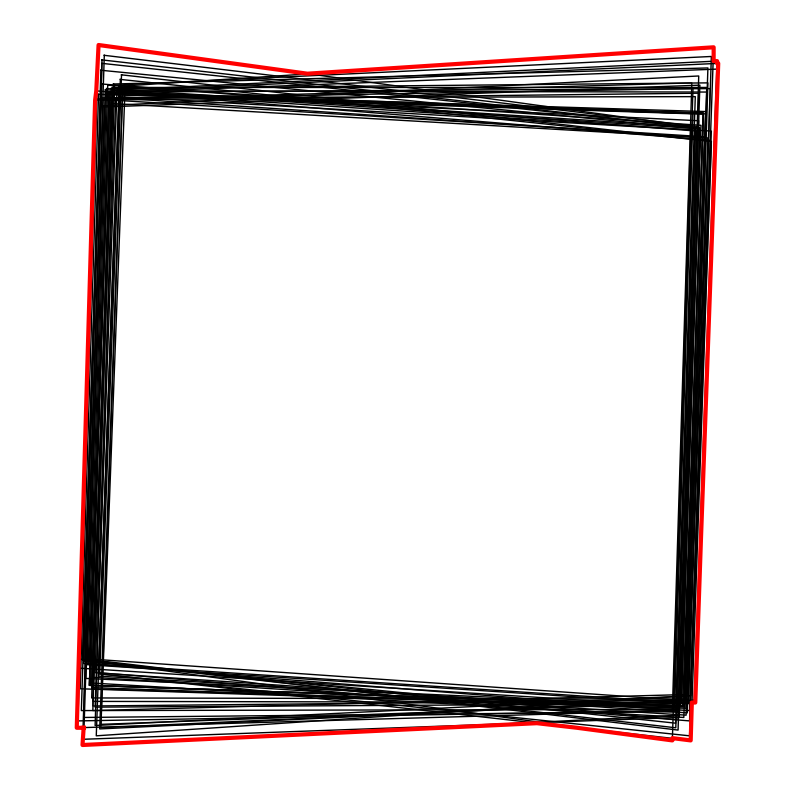

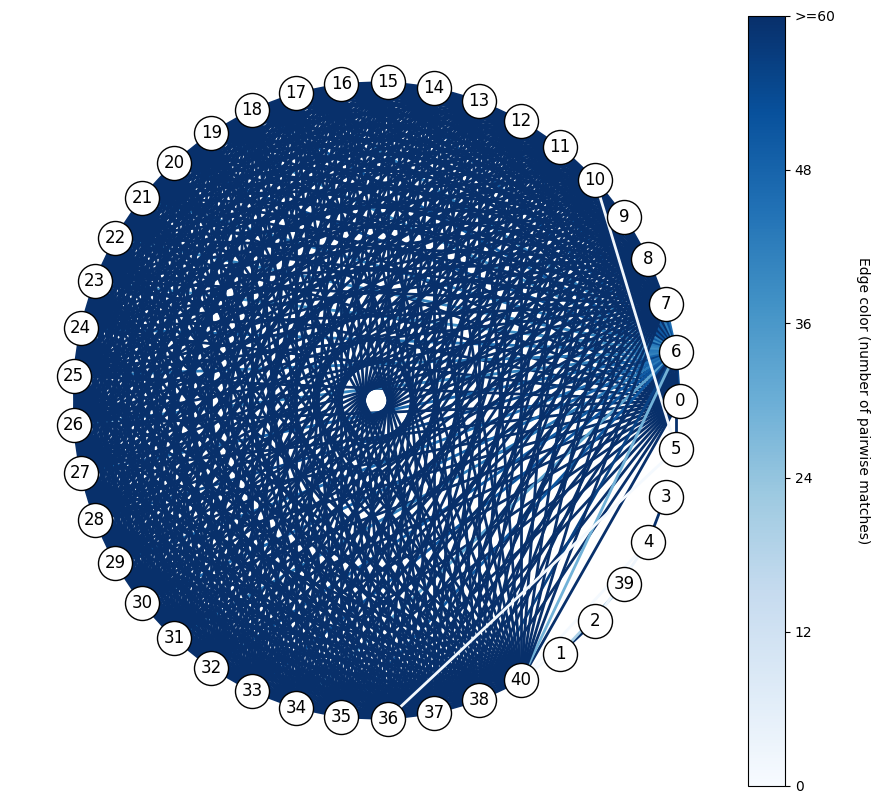

All done! Path to bundle-adjusted root_dir: /mnt/cdisk/roger/lightglue_ba_outputs/OMA_177/root_dir_ba/OMA_177


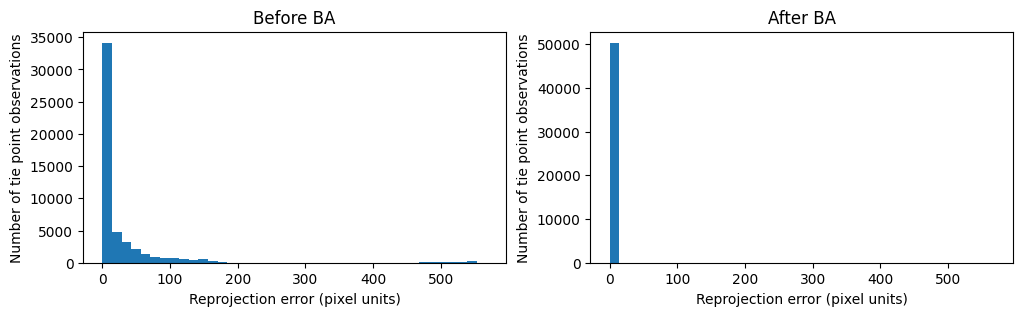

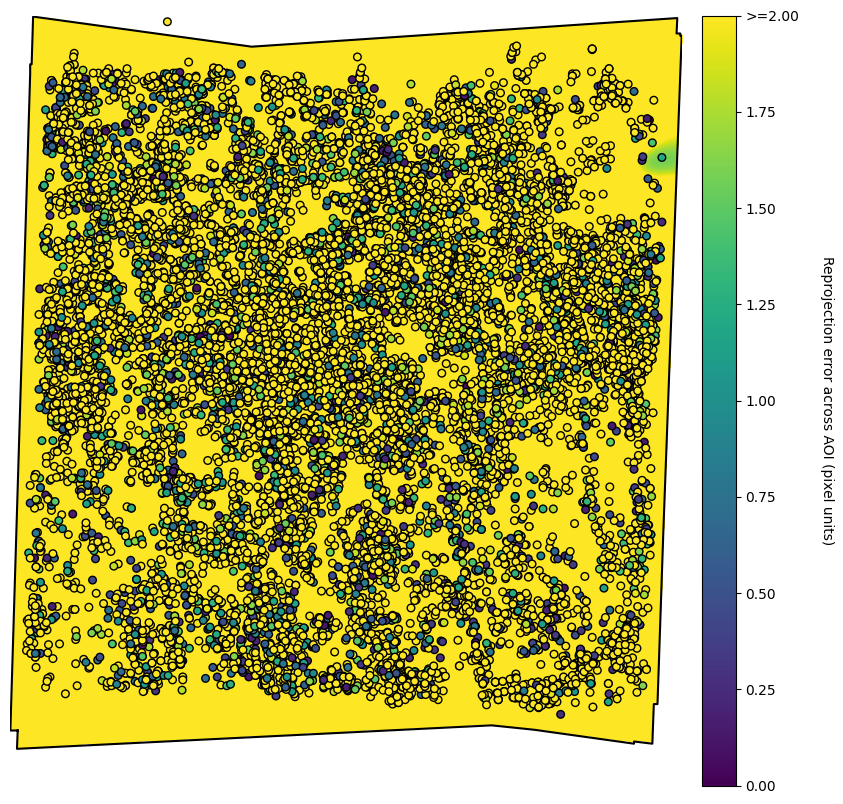

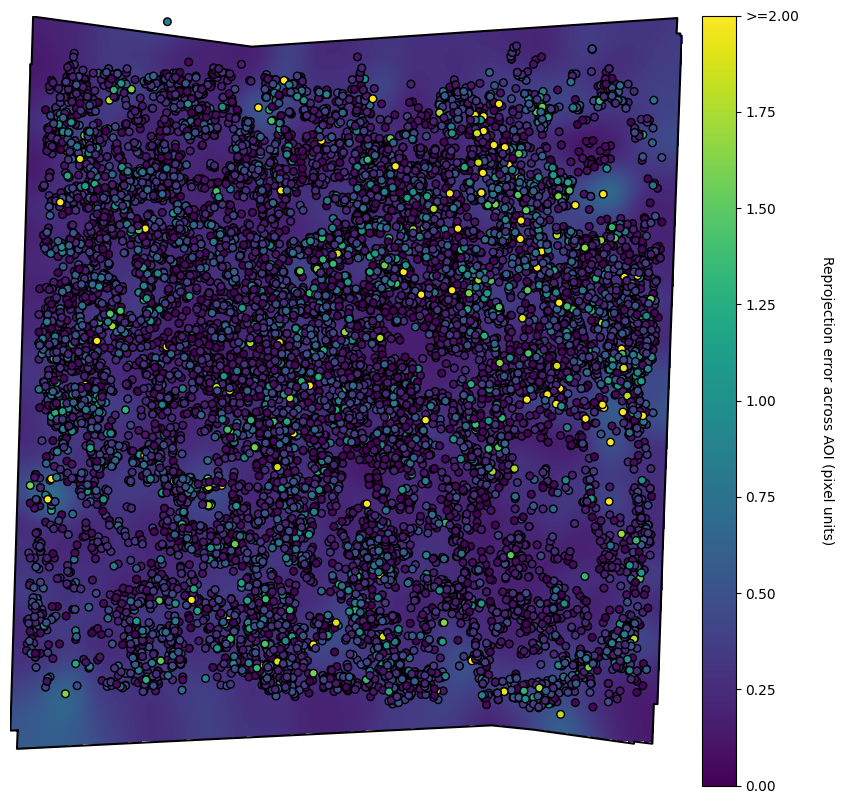

In [2]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"

IMAGES_TO_IGNORE = {
    "JAX": ["6", "8", "9"],
    "UCSD": ["30", "31", "7"],
    "OMA": ["12"]
}

def rpc_from_json(json_path, return_dict=False):
    with open(json_path) as f:
        d = json.load(f)
    if return_dict:
        return d["rpc"]
    return rpcm.RPCModel(d["rpc"], dict_format="rpcm")

def run_ba(dataset_path, aoi_id, output_dir=None, save_tmp_files=False, overwrite=False, max_keypoints=None, dem_file=None):

    from bundle_adjust.cam_utils import SatelliteImage
    from bundle_adjust.ba_pipeline import BundleAdjustmentPipeline
    from bundle_adjust import loader

    run_ba = True

    img_dir = os.path.join(dataset_path, "crops", aoi_id)
    in_rpc_dir = os.path.join(dataset_path, "root", aoi_id)
    if output_dir is None:
        out_rpc_dir = os.path.join(dataset_path, "root_dir_ba", aoi_id)
        ba_files_dir = os.path.join(dataset_path, "ba_files", aoi_id)
    else:
        out_rpc_dir = os.path.join(output_dir, "root_dir_ba", aoi_id)
        ba_files_dir = os.path.join(output_dir, "ba_files", aoi_id)


    # overwrite if needed
    if os.path.exists(out_rpc_dir) and not overwrite:
        print("Output_dir already exists! Skipping!\n")
        return None
    else:
        os.makedirs(out_rpc_dir, exist_ok=True)

    # load input data
    myimages = sorted(glob.glob(img_dir + "/*.tif"))
    # Ignore badly localized images
    myimages = [im for im in myimages if os.path.basename(im).split("_")[-2].split(".")[0] not in IMAGES_TO_IGNORE.get(aoi_id.split("_")[0], [])]
    myjsons = [os.path.join(in_rpc_dir, os.path.basename(p).replace(".tif", ".json")) for p in myimages]
    for p1, p2 in zip(myjsons, myimages):
        assert os.path.exists(p1) and os.path.exists(p2)
    #myrpcs = [rpcm.rpc_from_geotiff(p) for p in mypanimages]
    myrpcs = [rpc_from_json(p) for p in myjsons]
    input_images = [SatelliteImage(fn, rpc) for fn, rpc in zip(myimages, myrpcs)]
    ba_input_data = {}
    ba_input_data['in_dir'] = img_dir
    ba_input_data['out_dir'] = ba_files_dir
    ba_input_data['images'] = input_images

    print('Input data successfully set!\n')

    # redirect all prints to a bundle adjustment logfile inside the output directory
    os.makedirs(ba_input_data['out_dir'], exist_ok=True)
    path_to_log_file = "{}/bundle_adjust.log".format(ba_input_data['out_dir'])
    print("Running bundle adjustment for RPC model refinement ...")
    print(f"Path to log file: {path_to_log_file}")
    log_file = open(path_to_log_file, "w+")
    sys.stdout = log_file
    sys.stderr = log_file
    # run bundle adjustment
    #tracks_config = {'FT_reset': True, 'FT_sift_detection': 's2p', 'FT_sift_matching': 'epipolar_based', "FT_K": 300}
    # tracks_config = {'FT_reset': False, 'FT_save': True, 'FT_sift_detection': 's2p', 'FT_sift_matching': 'epipolar_based', "FT_kp_max": 20000, "FT_n_proc": 12}
    if max_keypoints is None:
        tracks_config = {'FT_reset': False, 'FT_save': True, 'FT_sift_detection': 's2p', 'FT_sift_matching': 'epipolar_based', "FT_n_proc": 12}
    else:
        tracks_config = {'FT_reset': False, 'FT_save': True, 'FT_sift_detection': 's2p', 'FT_sift_matching': 'epipolar_based', "FT_kp_max": max_keypoints, "FT_n_proc": 12}
    ba_extra = {"cam_model": "rpc", "dem_file": dem_file}
    #tracks_config['FT_sift_matching'] = 'lightglue'
    tracks_config['FT_sift_matching'] = 'flann'
    tracks_config['FT_challenging_images'] = [1, 2, 3, 4, 5, 6, 7, 39, 40]

    ba_pipeline = BundleAdjustmentPipeline(ba_input_data, tracks_config=tracks_config, extra_ba_config=ba_extra)
    ba_pipeline.run()
    # close logfile
    sys.stderr = sys.__stderr__
    sys.stdout = sys.__stdout__
    log_file.close()
    print("... done !")
    print(f"Path to bundle adjustment files: {ba_input_data['out_dir']}")


    # save all bundle adjustment parameters in a temporary directory if needed for debugging
    if save_tmp_files:
        ba_params_dir = os.path.join(ba_pipeline.out_dir, "ba_params")
        os.makedirs(ba_params_dir, exist_ok=True)
        np.save(os.path.join(ba_params_dir, "pts_ind.npy"), ba_pipeline.ba_params.pts_ind)
        np.save(os.path.join(ba_params_dir, "cam_ind.npy"), ba_pipeline.ba_params.cam_ind)
        np.save(os.path.join(ba_params_dir, "pts3d.npy"), ba_pipeline.ba_params.pts3d_ba - ba_pipeline.global_transform)
        np.save(os.path.join(ba_params_dir, "pts2d.npy"), ba_pipeline.ba_params.pts2d)
        fnames_in_use = [ba_pipeline.images[idx].geotiff_path for idx in ba_pipeline.ba_params.cam_prev_indices]
        loader.save_list_of_paths(os.path.join(ba_params_dir, "geotiff_paths.txt"), fnames_in_use)

    for in_json_path in myjsons:
        with open(in_json_path) as f:
            d = json.load(f)
        rpc_adj_path = os.path.join(ba_files_dir, f"rpcs_adj/{os.path.basename(in_json_path).replace('.json', '.rpc_adj')}")
        if not os.path.exists(rpc_adj_path):
            continue
        d["rpc"] = rpcm.rpc_from_rpc_file(rpc_adj_path).__dict__
        out_json_path = os.path.join(out_rpc_dir, os.path.basename(in_json_path))
        os.makedirs(out_rpc_dir, exist_ok=True)
        with open(out_json_path, "w") as f:
            json.dump(d, f, indent=2)
    print(f"All done! Path to bundle-adjusted root_dir: {out_rpc_dir}")


dataset_path = "/mnt/cdisk/emasquil/shadow_dataset"
aoi_id = "OMA_177"
output_dir = "/mnt/cdisk/roger/lightglue_ba_outputs/OMA_177"
max_kps = 10000

run_ba(dataset_path, aoi_id, output_dir=output_dir, save_tmp_files=False, overwrite=True, max_keypoints=max_kps, dem_file=None)